In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import least_squares

from model import (
    simulate_monod, residuals_monod,
    simulate_haldane, residuals_haldane,
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

# Load the same data + re-fit both models so all variables are in this kernel
df = pd.read_csv('../data/synthetic_batch_fermentation.csv')
t_data = df['time_h'].values
X_data = df['biomass_gL'].values
S_data = df['substrate_gL'].values
X0, S0 = X_data[0], S_data[0]

# Re-fit Monod
result_monod = least_squares(
    residuals_monod, x0=[0.4, 0.1, 0.5],
    bounds=([0.01, 0.001, 0.1], [2.0, 10.0, 1.0]),
    args=(t_data, X_data, S_data, X0, S0), method='trf', verbose=0,
)

# Re-fit Haldane
result_haldane = least_squares(
    residuals_haldane, x0=[0.4, 0.1, 100, 0.5],
    bounds=([0.01, 0.001, 0.1, 0.1], [2.0, 10.0, 1000.0, 1.0]),
    args=(t_data, X_data, S_data, X0, S0), method='trf', verbose=0,
)

print("Monod params:  ", result_monod.x)
print("Haldane params:", result_haldane.x)

Monod params:   [0.48022106 0.72439241 0.44410852]
Haldane params: [4.86257374e-01 7.61041614e-01 1.00000000e+03 4.44138098e-01]


In [3]:
# Get predicted X and S at each data time point, for both models
X_pred_monod, S_pred_monod = simulate_monod(result_monod.x, t_data, X0, S0)
X_pred_haldane, S_pred_haldane = simulate_haldane(result_haldane.x, t_data, X0, S0)

# Raw (unnormalized) residuals — these are in the original biological units
res_X_monod   = X_data - X_pred_monod
res_S_monod   = S_data - S_pred_monod
res_X_haldane = X_data - X_pred_haldane
res_S_haldane = S_data - S_pred_haldane

# Quick summary
print(f"Monod biomass residuals:   mean = {np.mean(res_X_monod):+.4f}, std = {np.std(res_X_monod):.4f}")
print(f"Monod substrate residuals: mean = {np.mean(res_S_monod):+.4f}, std = {np.std(res_S_monod):.4f}")
print(f"Haldane biomass residuals: mean = {np.mean(res_X_haldane):+.4f}, std = {np.std(res_X_haldane):.4f}")
print(f"Haldane substrate residuals: mean = {np.mean(res_S_haldane):+.4f}, std = {np.std(res_S_haldane):.4f}")

Monod biomass residuals:   mean = -0.0183, std = 0.1684
Monod substrate residuals: mean = -0.3327, std = 0.4917
Haldane biomass residuals: mean = -0.0181, std = 0.1685
Haldane substrate residuals: mean = -0.3335, std = 0.4921


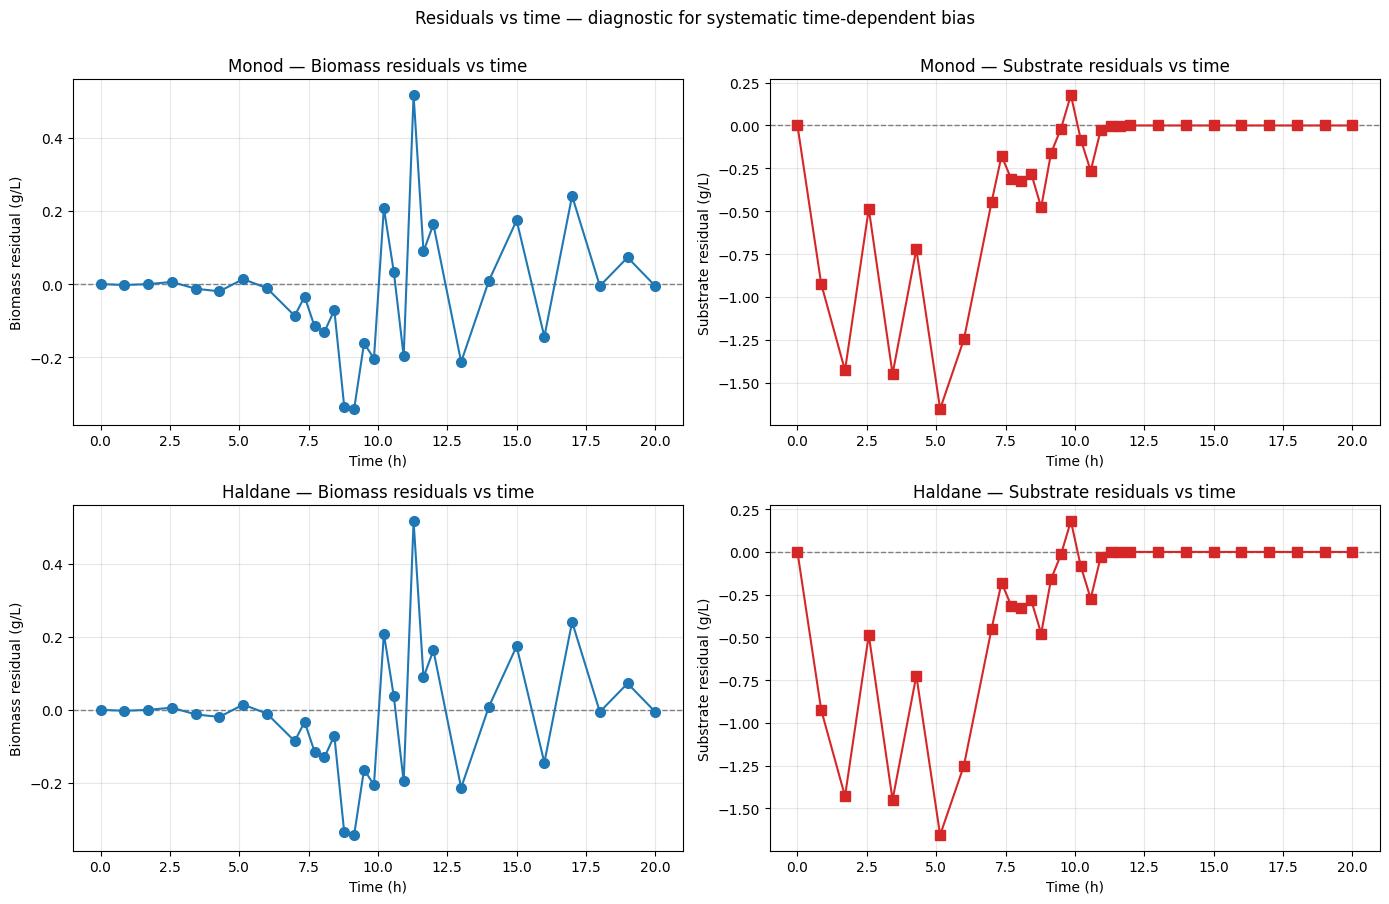

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Monod — biomass
axes[0,0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0,0].plot(t_data, res_X_monod, 'o-', color='C0', markersize=7)
axes[0,0].set_xlabel('Time (h)')
axes[0,0].set_ylabel('Biomass residual (g/L)')
axes[0,0].set_title('Monod — Biomass residuals vs time')
axes[0,0].grid(alpha=0.3)

# Monod — substrate
axes[0,1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0,1].plot(t_data, res_S_monod, 's-', color='C3', markersize=7)
axes[0,1].set_xlabel('Time (h)')
axes[0,1].set_ylabel('Substrate residual (g/L)')
axes[0,1].set_title('Monod — Substrate residuals vs time')
axes[0,1].grid(alpha=0.3)

# Haldane — biomass
axes[1,0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1,0].plot(t_data, res_X_haldane, 'o-', color='C0', markersize=7)
axes[1,0].set_xlabel('Time (h)')
axes[1,0].set_ylabel('Biomass residual (g/L)')
axes[1,0].set_title('Haldane — Biomass residuals vs time')
axes[1,0].grid(alpha=0.3)

# Haldane — substrate
axes[1,1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1,1].plot(t_data, res_S_haldane, 's-', color='C3', markersize=7)
axes[1,1].set_xlabel('Time (h)')
axes[1,1].set_ylabel('Substrate residual (g/L)')
axes[1,1].set_title('Haldane — Substrate residuals vs time')
axes[1,1].grid(alpha=0.3)

plt.suptitle('Residuals vs time — diagnostic for systematic time-dependent bias', y=1.00)
plt.tight_layout()
plt.savefig('../figures/05_residuals_vs_time.png', bbox_inches='tight')
plt.show()

**Observation:** Biomass residuals scatter randomly around zero with no
time-dependent trend. Substrate residuals show a slight negative bias
(consistently below zero), consistent with the Ks over-estimation noted earlier.


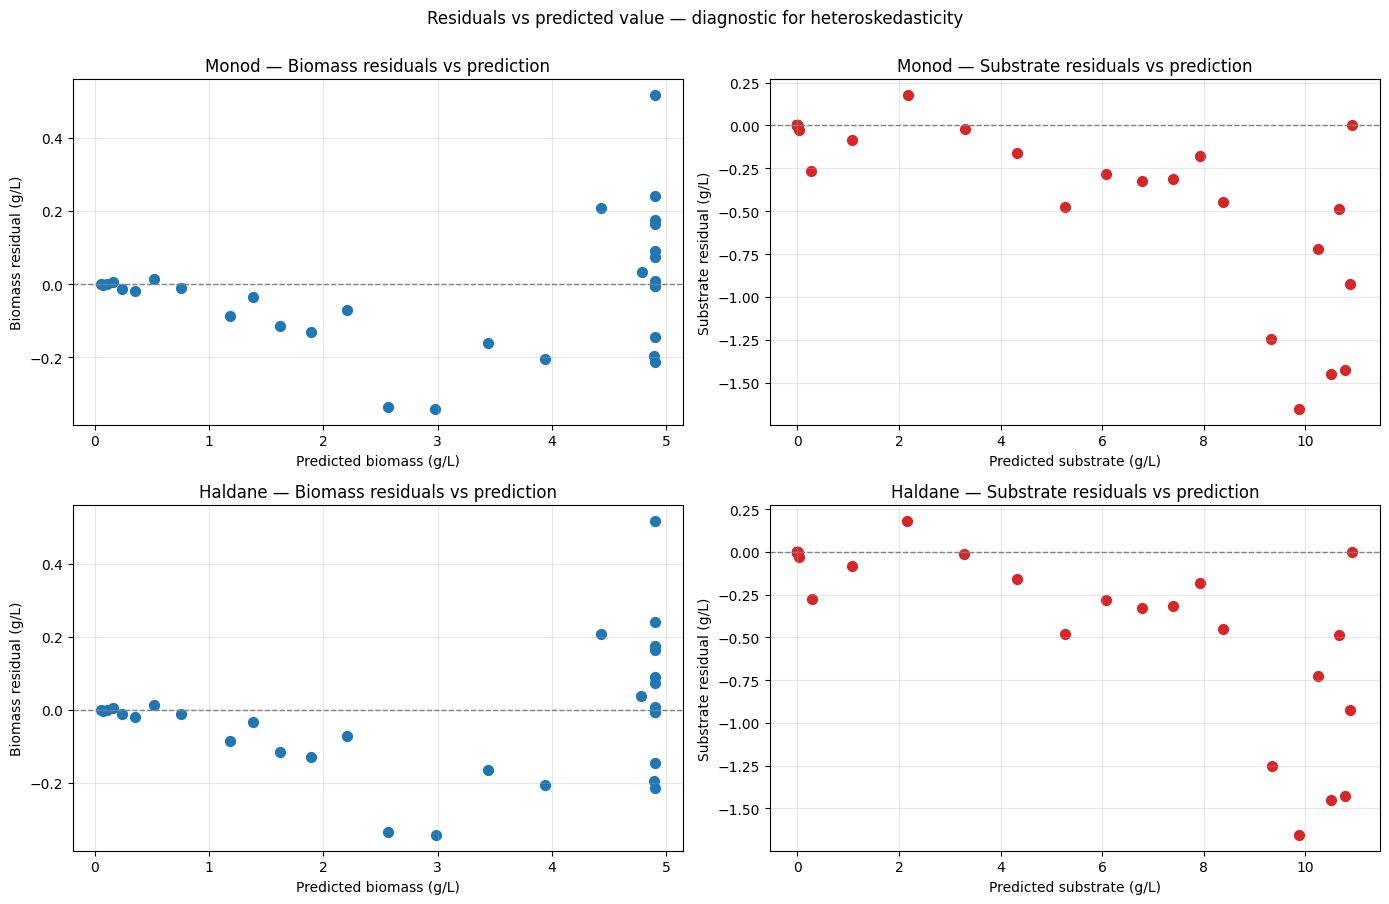

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Monod — biomass
axes[0,0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0,0].scatter(X_pred_monod, res_X_monod, color='C0', s=50)
axes[0,0].set_xlabel('Predicted biomass (g/L)')
axes[0,0].set_ylabel('Biomass residual (g/L)')
axes[0,0].set_title('Monod — Biomass residuals vs prediction')
axes[0,0].grid(alpha=0.3)

# Monod — substrate
axes[0,1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0,1].scatter(S_pred_monod, res_S_monod, color='C3', s=50)
axes[0,1].set_xlabel('Predicted substrate (g/L)')
axes[0,1].set_ylabel('Substrate residual (g/L)')
axes[0,1].set_title('Monod — Substrate residuals vs prediction')
axes[0,1].grid(alpha=0.3)

# Haldane — biomass
axes[1,0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1,0].scatter(X_pred_haldane, res_X_haldane, color='C0', s=50)
axes[1,0].set_xlabel('Predicted biomass (g/L)')
axes[1,0].set_ylabel('Biomass residual (g/L)')
axes[1,0].set_title('Haldane — Biomass residuals vs prediction')
axes[1,0].grid(alpha=0.3)

# Haldane — substrate
axes[1,1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1,1].scatter(S_pred_haldane, res_S_haldane, color='C3', s=50)
axes[1,1].set_xlabel('Predicted substrate (g/L)')
axes[1,1].set_ylabel('Substrate residual (g/L)')
axes[1,1].set_title('Haldane — Substrate residuals vs prediction')
axes[1,1].grid(alpha=0.3)

plt.suptitle('Residuals vs predicted value — diagnostic for heteroskedasticity', y=1.00)
plt.tight_layout()
plt.savefig('../figures/06_residuals_vs_prediction.png', bbox_inches='tight')
plt.show()

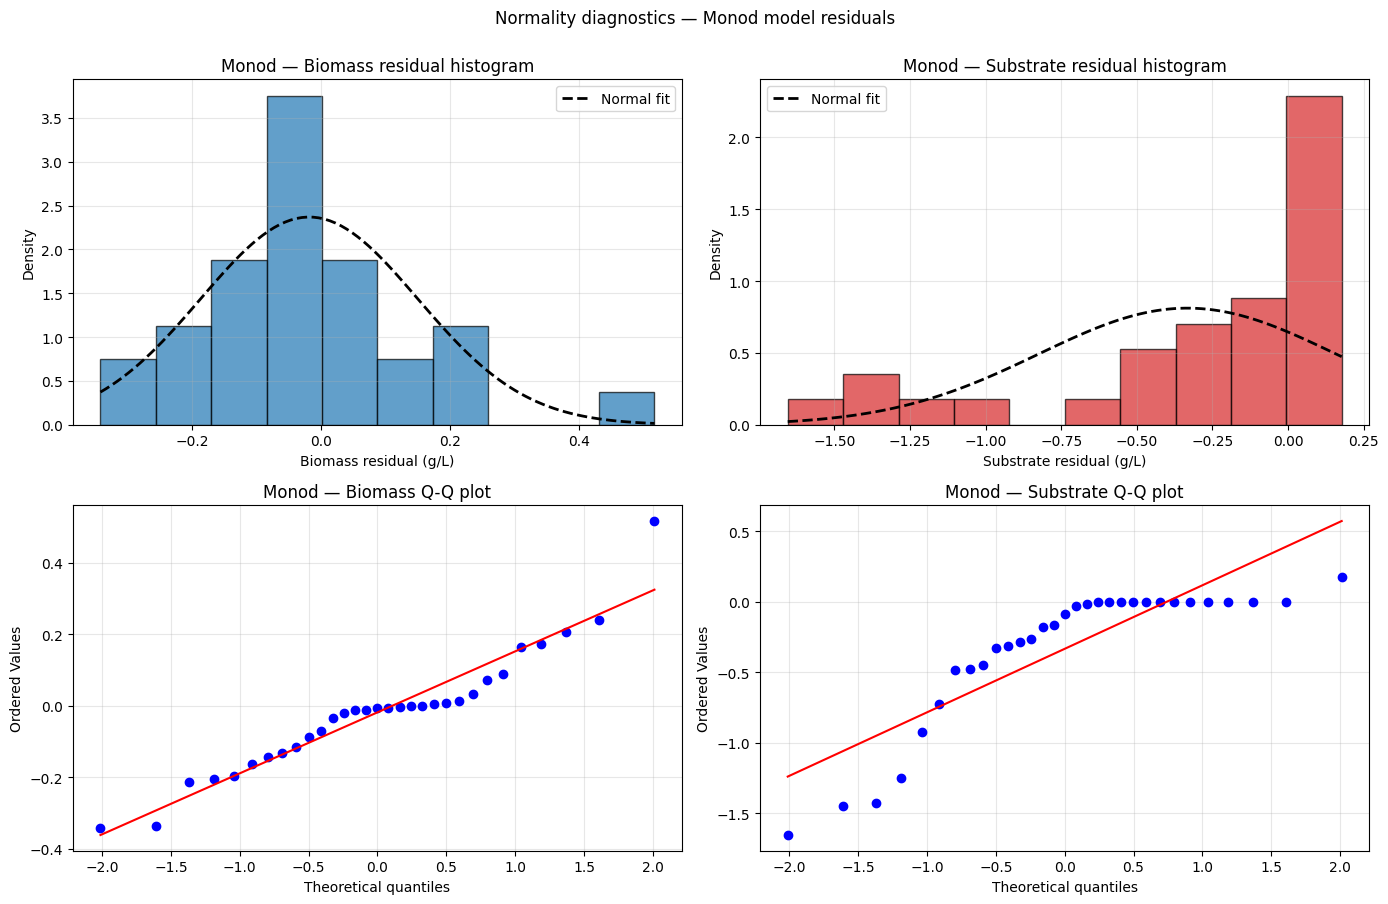

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Histogram of Monod biomass residuals with normal overlay
axes[0,0].hist(res_X_monod, bins=10, color='C0', alpha=0.7, edgecolor='black', density=True)
x_range = np.linspace(res_X_monod.min(), res_X_monod.max(), 100)
axes[0,0].plot(x_range,
               stats.norm.pdf(x_range, np.mean(res_X_monod), np.std(res_X_monod)),
               'k--', linewidth=2, label='Normal fit')
axes[0,0].set_xlabel('Biomass residual (g/L)')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Monod — Biomass residual histogram')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# Histogram of Monod substrate residuals
axes[0,1].hist(res_S_monod, bins=10, color='C3', alpha=0.7, edgecolor='black', density=True)
x_range = np.linspace(res_S_monod.min(), res_S_monod.max(), 100)
axes[0,1].plot(x_range,
               stats.norm.pdf(x_range, np.mean(res_S_monod), np.std(res_S_monod)),
               'k--', linewidth=2, label='Normal fit')
axes[0,1].set_xlabel('Substrate residual (g/L)')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Monod — Substrate residual histogram')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Q-Q plot for Monod biomass
stats.probplot(res_X_monod, dist='norm', plot=axes[1,0])
axes[1,0].set_title('Monod — Biomass Q-Q plot')
axes[1,0].grid(alpha=0.3)

# Q-Q plot for Monod substrate
stats.probplot(res_S_monod, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Monod — Substrate Q-Q plot')
axes[1,1].grid(alpha=0.3)

plt.suptitle('Normality diagnostics — Monod model residuals', y=1.00)
plt.tight_layout()
plt.savefig('../figures/07_normality_check.png', bbox_inches='tight')
plt.show()

**Observation:** Biomass residuals are consistent with normality (Shapiro-Wilk
p = 0.067). Substrate residuals strongly reject normality (p < 0.001), reflecting
the heteroskedastic relative-noise structure of the data — variance scales with
substrate concentration and collapses near depletion. The Q-Q plot confirms this:
biomass tracks the diagonal, substrate deviates at the tails.

In [7]:
# Shapiro-Wilk normality test (the standard small-sample test)
sw_X_monod = stats.shapiro(res_X_monod)
sw_S_monod = stats.shapiro(res_S_monod)
sw_X_haldane = stats.shapiro(res_X_haldane)
sw_S_haldane = stats.shapiro(res_S_haldane)

print("Shapiro-Wilk test for normality (null hypothesis: residuals are normal)")
print(f"  Monod biomass:    W = {sw_X_monod.statistic:.4f}, p = {sw_X_monod.pvalue:.4f}")
print(f"  Monod substrate:  W = {sw_S_monod.statistic:.4f}, p = {sw_S_monod.pvalue:.4f}")
print(f"  Haldane biomass:  W = {sw_X_haldane.statistic:.4f}, p = {sw_X_haldane.pvalue:.4f}")
print(f"  Haldane substrate: W = {sw_S_haldane.statistic:.4f}, p = {sw_S_haldane.pvalue:.4f}")
print()
print("Interpretation: p > 0.05 means we fail to reject normality (residuals consistent with Gaussian).")
print("                p < 0.05 means residuals show significant non-normality.")

Shapiro-Wilk test for normality (null hypothesis: residuals are normal)
  Monod biomass:    W = 0.9368, p = 0.0673
  Monod substrate:  W = 0.7526, p = 0.0000
  Haldane biomass:  W = 0.9373, p = 0.0696
  Haldane substrate: W = 0.7540, p = 0.0000

Interpretation: p > 0.05 means we fail to reject normality (residuals consistent with Gaussian).
                p < 0.05 means residuals show significant non-normality.
